# Task 2: Predict Future Stock Prices

## Objective
Predict the next day's stock closing price using historical stock market data.

## Stock Selected
Apple (AAPL)

## Tools Used
- Python
- Pandas
- yfinance
- Scikit-Learn
- Matplotlib

In [2]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   -------------------------------

In [5]:
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
stock = yf.download("AAPL",
                    start="2020-01-01",
                    end="2025-01-01")

stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017815,73.318854,71.565599,71.565599,132079200


In [7]:
print(stock.shape)

stock.info()

stock.describe()

(1258, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377786,152.899566,149.680872,151.223470,9.057103e+07
std,41.851999,41.992363,41.629303,41.795805,5.324438e+07
min,54.163692,55.160690,51.324789,55.059301,2.323470e+07
25%,126.279116,127.397087,124.278487,125.724399,5.546825e+07
50%,149.968597,151.709757,148.037172,149.788913,7.628335e+07
75%,175.902035,177.452421,174.337238,175.708219,1.077425e+08
max,257.375549,258.448710,255.994390,256.550832,4.265100e+08


In [8]:
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017815,73.318854,71.565599,71.565599,132079200


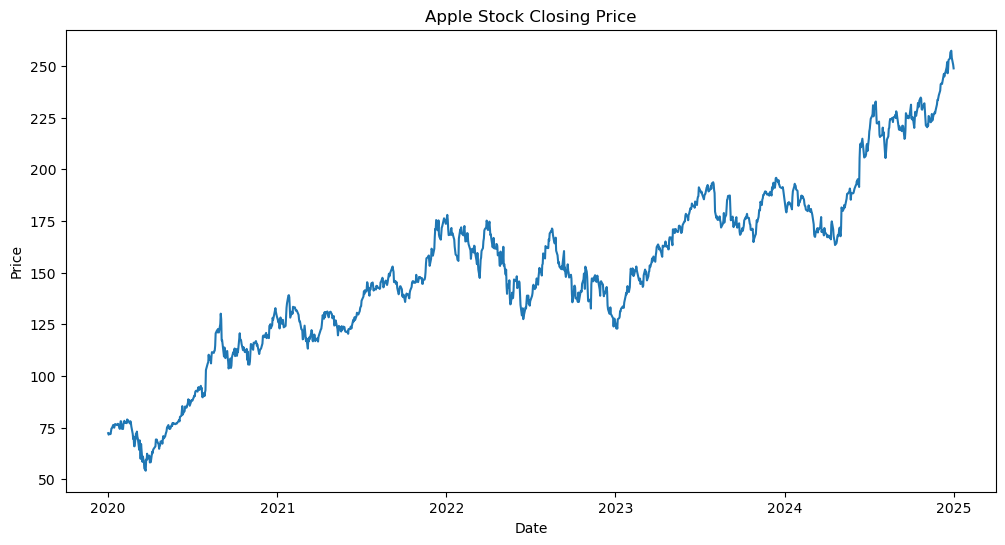

In [9]:
plt.figure(figsize=(12,6))

plt.plot(stock['Close'])

plt.title("Apple Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

In [11]:
stock['Target'] = stock['Close'].shift(-1)

stock = stock.dropna()

stock.head()

Price,Close,High,Low,Open,Volume,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400,71.630653
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800,72.201424
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,71.861855
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,73.017815
2020-01-08,73.017815,73.318854,71.565599,71.565599,132079200,74.568756


In [12]:
X = stock[['Open',
           'High',
           'Low',
           'Volume']]

y = stock['Target']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
predictions = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 2.086167157593505
RMSE: 2.879851913163339
R2 Score: 0.9952642079847975


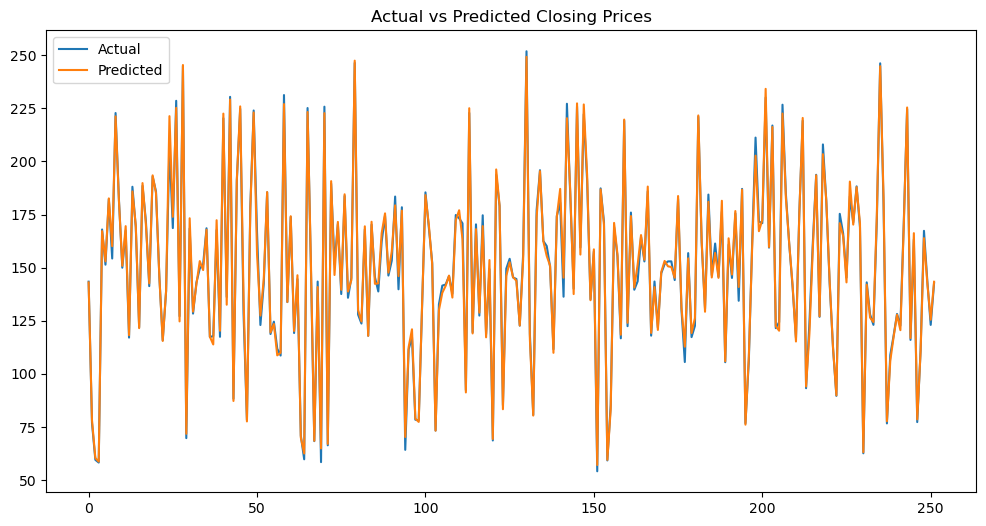

In [17]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values,
         label='Actual')

plt.plot(predictions,
         label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Closing Prices")

plt.show()

Predicted Next Day Closing Price:
250.75460044691766


# Results and Findings

1. Historical stock data was downloaded using yfinance.
2. Open, High, Low and Volume were used as input features.
3. Linear Regression model was trained.
4. Model performance was evaluated using MAE, RMSE and R² Score.
5. Predicted prices closely followed actual prices.
6. The model successfully estimated the next day's closing price.